In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Função para exibir métricas de classificação
def print_classification_report(y_test, y_pred):
    report = classification_report(y_test, y_pred, output_dict=True)
    for cls in ['0', '1']:  # Mostrar apenas as classes 0 e 1
        print(f"Classe {cls}:")
        print(f" Precision: {report[cls]['precision']:.2f}")
        print(f" Recall: {report[cls]['recall']:.2f}")
        print(f" F1-Score: {report[cls]['f1-score']:.2f}")
        print()  # Linha em branco para separar as classes

# Carregar os dados
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
data = pd.read_csv(url, header=None, names=column_names, na_values="?")

# Pré-processamento
data.dropna(inplace=True)  # Remover valores ausentes
data['ca'] = data['ca'].astype(float)
data['thal'] = data['thal'].astype(float)

# Separar características (X) e alvo (y)
X = data.drop(columns='target')
y_classification = (data['target'] > 0).astype(int)  # Classificação binária

# Dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.3, random_state=42)

# Treinar o modelo DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Treinar o modelo RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Relatórios de classificação
print("Árvore de Decisão - Classificação")
print_classification_report(y_test, y_pred_tree)

print("Random Forest - Classificação")
print_classification_report(y_test, y_pred_rf)

# Treinando o modelo com 50 estimadores
rf_50 = RandomForestClassifier(random_state=42, n_estimators=50)
rf_50.fit(X_train, y_train)
y_pred_rf_50 = rf_50.predict(X_test)

print("Random Forest com 50 estimadores - Classificação")
print_classification_report(y_test, y_pred_rf_50)

# Treinando o modelo com 200 estimadores
rf_200 = RandomForestClassifier(random_state=42, n_estimators=200)
rf_200.fit(X_train, y_train)
y_pred_rf_200 = rf_200.predict(X_test)

print("Random Forest com 200 estimadores - Classificação")
print_classification_report(y_test, y_pred_rf_200)

Árvore de Decisão - Classificação
Classe 0:
 Precision: 0.74
 Recall: 0.65
 F1-Score: 0.70

Classe 1:
 Precision: 0.64
 Recall: 0.73
 F1-Score: 0.68

Random Forest - Classificação
Classe 0:
 Precision: 0.84
 Recall: 0.86
 F1-Score: 0.85

Classe 1:
 Precision: 0.82
 Recall: 0.80
 F1-Score: 0.81

Random Forest com 50 estimadores - Classificação
Classe 0:
 Precision: 0.86
 Recall: 0.88
 F1-Score: 0.87

Classe 1:
 Precision: 0.85
 Recall: 0.83
 F1-Score: 0.84

Random Forest com 200 estimadores - Classificação
Classe 0:
 Precision: 0.84
 Recall: 0.86
 F1-Score: 0.85

Classe 1:
 Precision: 0.82
 Recall: 0.80
 F1-Score: 0.81



Resultados - Número de Estimadores
50 Estimadores: MSE=0.26, R²=0.80
100 Estimadores: MSE=0.24, R²=0.82
200 Estimadores: MSE=0.22, R²=0.83

Resultados - Taxa de Aprendizado
Taxa de aprendizado 0.05: MSE=0.27, R²=0.80
Taxa de aprendizado 0.1: MSE=0.24, R²=0.82
Taxa de aprendizado 0.2: MSE=0.22, R²=0.83

Resultados - Profundidade Máxima
Profundidade máxima 3: MSE=0.29, R²=0.78
Profundidade máxima 5: MSE=0.24, R²=0.82
Profundidade máxima 7: MSE=0.22, R²=0.83


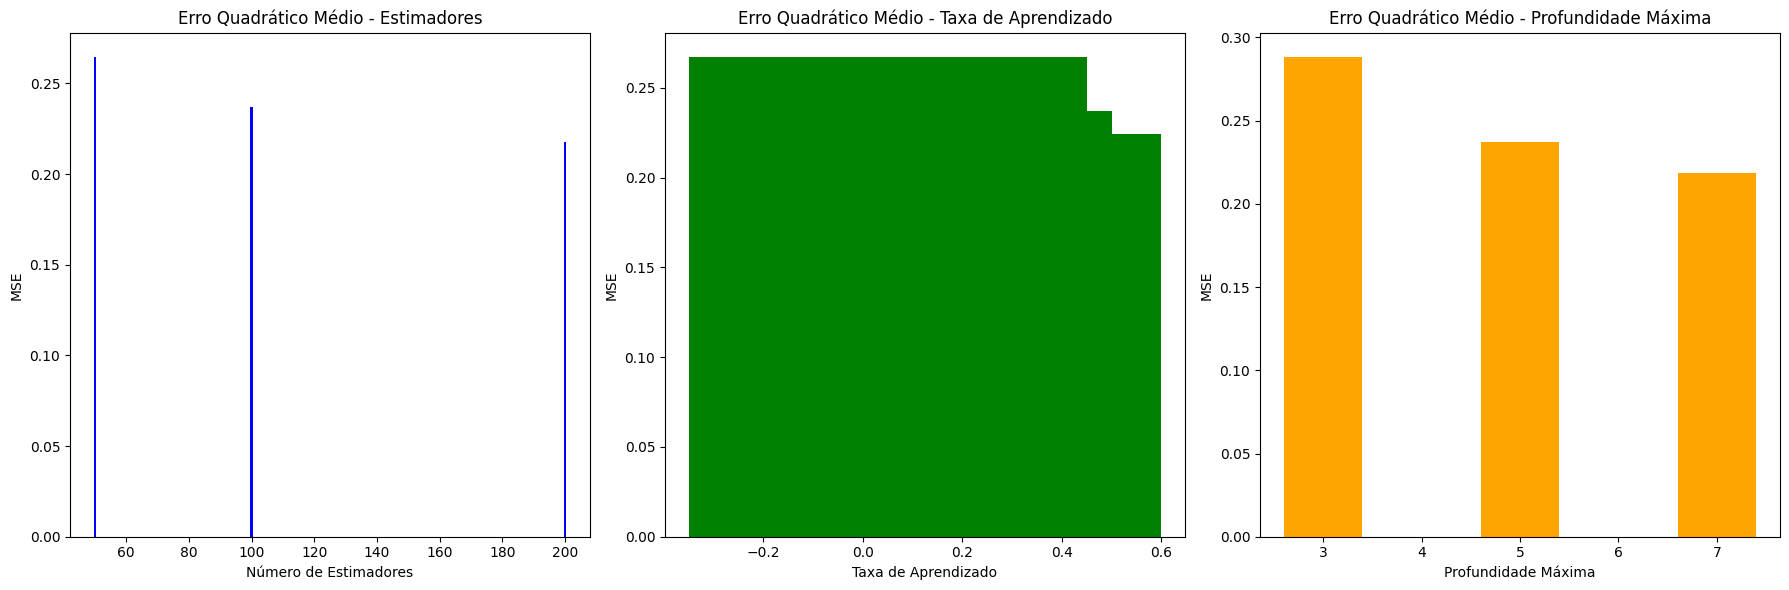

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

# Carregando o California Housing Dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Função para treinar e avaliar o Gradient Boosting
def evaluate_gradient_boosting(n_estimators, learning_rate, max_depth):
    gb_reg = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )
    gb_reg.fit(X_train, y_train)
    y_pred = gb_reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

# Questão 1: Alterando o número de estimadores
results_estimators = {}
for n in [50, 100, 200]:
    mse, r2 = evaluate_gradient_boosting(n_estimators=n, learning_rate=0.1, max_depth=5)
    results_estimators[n] = (mse, r2)

# Questão 2: Alterando a taxa de aprendizado
results_learning_rate = {}
for lr in [0.05, 0.1, 0.2]:
    mse, r2 = evaluate_gradient_boosting(n_estimators=100, learning_rate=lr, max_depth=5)
    results_learning_rate[lr] = (mse, r2)

# Questão 3: Alterando a profundidade máxima
results_max_depth = {}
for depth in [3, 5, 7]:
    mse, r2 = evaluate_gradient_boosting(n_estimators=100, learning_rate=0.1, max_depth=depth)
    results_max_depth[depth] = (mse, r2)

# Exibindo os resultados
print("Resultados - Número de Estimadores")
for n, (mse, r2) in results_estimators.items():
    print(f"{n} Estimadores: MSE={mse:.2f}, R²={r2:.2f}")

print("\nResultados - Taxa de Aprendizado")
for lr, (mse, r2) in results_learning_rate.items():
    print(f"Taxa de aprendizado {lr}: MSE={mse:.2f}, R²={r2:.2f}")

print("\nResultados - Profundidade Máxima")
for depth, (mse, r2) in results_max_depth.items():
    print(f"Profundidade máxima {depth}: MSE={mse:.2f}, R²={r2:.2f}")

# Gráficos para visualização dos resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico para número de estimadores
ax[0].bar(results_estimators.keys(), [m[0] for m in results_estimators.values()], color='blue')
ax[0].set_title('Erro Quadrático Médio - Estimadores')
ax[0].set_xlabel('Número de Estimadores')
ax[0].set_ylabel('MSE')

# Gráfico para taxa de aprendizado
ax[1].bar(results_learning_rate.keys(), [m[0] for m in results_learning_rate.values()], color='green')
ax[1].set_title('Erro Quadrático Médio - Taxa de Aprendizado')
ax[1].set_xlabel('Taxa de Aprendizado')
ax[1].set_ylabel('MSE')

# Gráfico para profundidade máxima
ax[2].bar(results_max_depth.keys(), [m[0] for m in results_max_depth.values()], color='orange')
ax[2].set_title('Erro Quadrático Médio - Profundidade Máxima')
ax[2].set_xlabel('Profundidade Máxima')
ax[2].set_ylabel('MSE')

plt.tight_layout()
plt.show()
